# Projeto em parceria com a Semanthix

**A desigualdade de desempenho no ENEM**


Quais fatores estão mais associados ao baixo desempenho dos estudantes no ENEM e como podemos identificar alunos com maior risco de baixo rendimento?


In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e divisão dos dados
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Métricas
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,

)

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC


In [2]:
df = pd.read_csv("MICRODADOS_ENEM_2023.csv", sep= ";", encoding="latin1")

In [3]:

df.head()


,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ANO_CONCLUIU,TP_ESCOLA,...,Q016,Q017,Q018,Q019,Q020,Q021,Q022,Q023,Q024,Q025
0,210059085136,2023,14,M,2,1,1,1,17,1,...,C,C,B,B,A,B,B,A,A,B
1,210059527735,2023,12,M,2,1,0,1,16,1,...,B,A,B,B,A,A,C,A,D,B
2,210061103945,2023,6,F,1,1,1,1,0,1,...,B,A,A,B,A,A,A,A,A,B
3,210060214087,2023,2,F,1,3,1,2,0,2,...,A,A,A,B,A,A,D,A,A,B
4,210059980948,2023,3,F,1,3,1,2,0,2,...,A,A,A,B,A,A,B,A,A,A


In [4]:
# Removendo identificadores e variavéis não relacionadas ao objetivo de analisar
# fatores associados ao desempenho no ENEM
colunas_remover = [
    "NU_INSCRICAO", "NU_ANO",
    "TP_ESTADO_CIVIL", "TP_NACIONALIDADE",
    "TP_ST_CONCLUSAO", "TP_ANO_CONCLUIU",
    "TP_ENSINO", "IN_TREINEIRO", "CO_MUNICIPIO_ESC",
    "CO_UF_ESC", "TP_LOCALIZACAO_ESC", "TP_SIT_FUNC_ESC",
    "CO_MUNICIPIO_PROVA", "CO_UF_PROVA", "TP_PRESENCA_CN",
    "TP_PRESENCA_CH", "TP_PRESENCA_LC", "TP_PRESENCA_MT",
    "CO_PROVA_CN", "CO_PROVA_CH", "CO_PROVA_LC", "CO_PROVA_MT",
    "TX_RESPOSTAS_CN", "TX_RESPOSTAS_CH", "TX_RESPOSTAS_LC",
    "TX_RESPOSTAS_MT", "TP_LINGUA", "TX_GABARITO_CN",
    "TX_GABARITO_CH", "TX_GABARITO_LC", "TX_GABARITO_MT",
    "TP_STATUS_REDACAO", "Q003", "Q004", "Q005",
    "Q007", "Q008", "Q009", "Q012", "Q013", "Q014", "Q015",
    "Q016", "Q017", "Q018", "Q019", "Q020", "Q021",

    ]

df = df.drop(columns=colunas_remover)


In [5]:
print(df.shape)

(50226, 28)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50226 entries, 0 to 50225
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   TP_FAIXA_ETARIA         50226 non-null  int64  
 1   TP_SEXO                 50226 non-null  object 
 2   TP_COR_RACA             50226 non-null  int64  
 3   TP_ESCOLA               50226 non-null  int64  
 4   NO_MUNICIPIO_ESC        10817 non-null  object 
 5   SG_UF_ESC               10817 non-null  object 
 6   TP_DEPENDENCIA_ADM_ESC  10817 non-null  float64
 7   NO_MUNICIPIO_PROVA      50226 non-null  object 
 8   SG_UF_PROVA             50226 non-null  object 
 9   NU_NOTA_CN              37983 non-null  float64
 10  NU_NOTA_CH              39388 non-null  float64
 11  NU_NOTA_LC              39388 non-null  float64
 12  NU_NOTA_MT              37983 non-null  float64
 13  NU_NOTA_COMP1           39387 non-null  float64
 14  NU_NOTA_COMP2           39387 non-null

In [7]:
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)

,0
SG_UF_ESC,78.463346
TP_DEPENDENCIA_ADM_ESC,78.463346
NO_MUNICIPIO_ESC,78.463346
NU_NOTA_CN,24.375821
NU_NOTA_MT,24.375821
NU_NOTA_COMP3,21.580456
NU_NOTA_COMP5,21.580456
NU_NOTA_REDACAO,21.580456
NU_NOTA_COMP1,21.580456
NU_NOTA_COMP2,21.580456


In [8]:
# Excluir as colunas com mais 75% de dados faltantes, essas variáveis podem gerar mais problemas do que benefícios.
# Excluir também as notas de competências
df.drop(
    columns=[
        'SG_UF_ESC', 'TP_DEPENDENCIA_ADM_ESC', 'NO_MUNICIPIO_ESC',
        'NU_NOTA_COMP1', 'NU_NOTA_COMP2', 'NU_NOTA_COMP3', 'NU_NOTA_COMP4',
        'NU_NOTA_COMP5'

    ], inplace=True
)

In [9]:
df = df.dropna(
    subset=[
        'NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT',
        'NU_NOTA_REDACAO'
    ]
).copy()
print(df.shape)

(37876, 20)


In [10]:
# Criando variável de desempenho
df['MEDIA_GERAL'] = (
    df['NU_NOTA_CN'] + df['NU_NOTA_CH'] + df['NU_NOTA_LC'] + df['NU_NOTA_MT']
) / 4


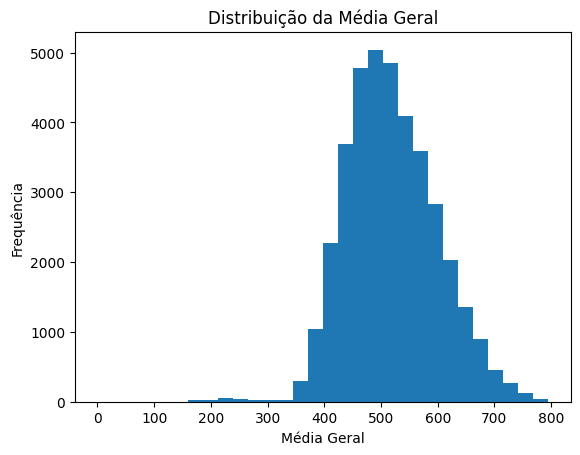

In [11]:
plt.hist(df['MEDIA_GERAL'], bins=30)
plt.xlabel('Média Geral')
plt.ylabel('Frequência')
plt.title('Distribuição da Média Geral')
plt.show()

A distribuição da média geral dos participantes do ENEM 2023 apresenta comportamento aproximadamente normal, com maior concentração de estudantes entre 450 e 650 pontos. Observa-se menor frequência de participantes nos extremos da distribuição, indicando que notas muito baixas ou muito altas são menos comuns.

In [12]:
df['MEDIA_GERAL'].describe()

,MEDIA_GERAL
count,37876.000000
mean,518.887622
std,80.133269
min,0.000000
25%,461.643750
50%,512.250000
75%,571.381250
max,795.050000


In [13]:
(df['MEDIA_GERAL'] == 0).sum()

np.int64(1)

 **Quais fatores estão mais associados ao desempenho?**

In [14]:
mapa_renda = {
    'A': 'Nenhuma renda',
    'B': 'Até R$ 1.320',
    'C': 'R$ 1.320 a R$ 1.980',
    'D': 'R$ 1.980 a R$ 2.640',
    'E': 'R$ 2.640 a R$ 3.300',
    'F': 'R$ 3.300 a R$ 3.960',
    'G': 'R$ 3.960 a R$ 5.280',
    'H': 'R$ 5.280 a R$ 6.600',
    'I': 'R$ 6.600 a R$ 7.920',
    'J': 'R$ 7.920 a R$ 9.240',
    'K': 'R$ 9.240 a R$ 10.560',
    'L': 'R$ 10.560 a R$ 11.880',
    'M': 'R$ 11.880 a R$ 13.200',
    'N': 'R$ 13.200 a R$ 15.840',
    'O': 'R$ 15.840 a R$ 19.800',
    'P': 'R$ 19.800 a R$ 26.400',
    'Q': 'Acima de R$ 26.400'
}

In [15]:
df['FAIXA_RENDA'] = df['Q006'].map(mapa_renda)

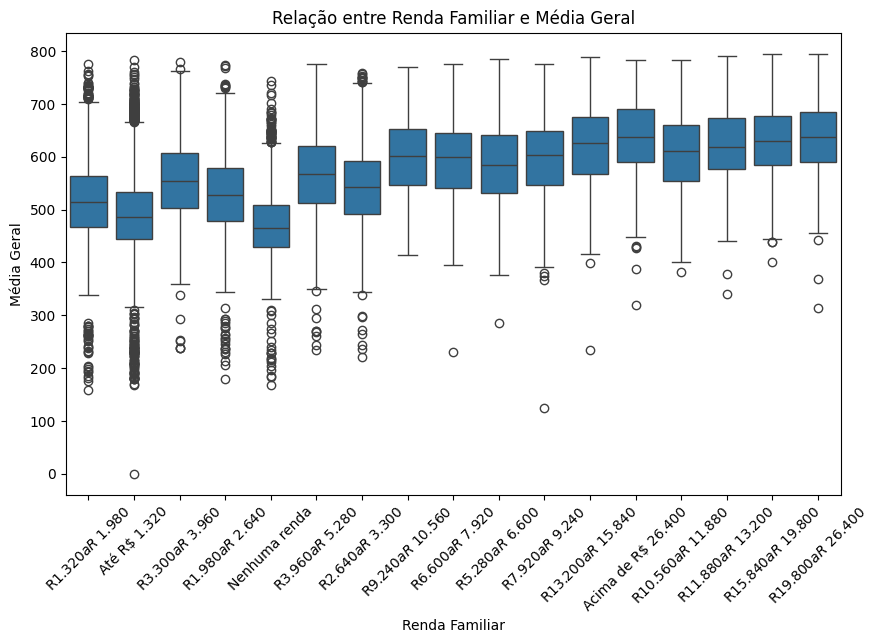

In [16]:
# Renda Familiar
ordem = list('ABCDEFGHIJKLMNOPQ')

plt.figure(figsize=(10, 6))
sns.boxplot(x='FAIXA_RENDA', y='MEDIA_GERAL', data=df)
plt.xlabel('Renda Familiar')
plt.ylabel('Média Geral')
plt.xticks(rotation=45)
plt.title('Relação entre Renda Familiar e Média Geral')
plt.show()

A análise indica uma associação positiva entre renda familiar e desempenho. Estudantes pertencentes às faixas de renda mais elevadas apresentam, em média, notas superiores às observadas nas faixas de menor renda, sugerindo que condições socioeconômicas podem influenciar o acesso a recursos educacionais.
Embora exista uma tendência geral de crescimento do desempenho com o aumento da renda familiar, observa-se sobreposição entre as distribuições, indicando que a renda não é o único fator associado ao desempenho dos estudantes.


In [17]:
mapa_escolaridade = {
    'A': 'Nunca estudou',
    'B': 'Fund. I incompleto',
    'C': 'Fund. I completo',
    'D': 'Fund. II completo',
    'E': 'Médio completo',
    'F': 'Superior completo',
    'G': 'Pós completo',
    'H': 'Não sei'
}

df['ESCOLARIDADE_MAE'] = df['Q002'].map(mapa_escolaridade)
df['ESCOLARIDADE_PAI'] = df['Q001'].map(mapa_escolaridade)

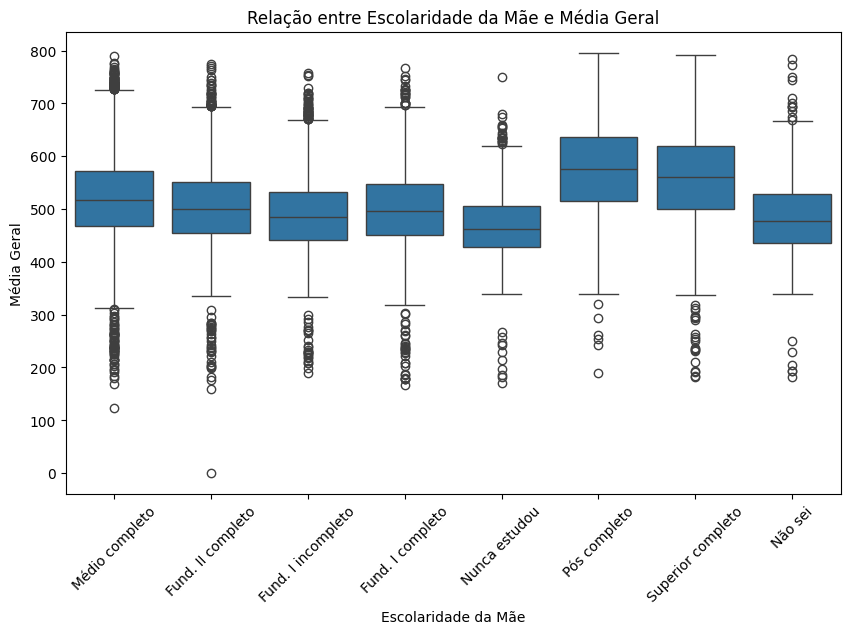

In [18]:
# Escolaridade da mãe
plt.figure(figsize=(10, 6))
sns.boxplot(x='ESCOLARIDADE_MAE', y='MEDIA_GERAL', data=df)
plt.xlabel('Escolaridade da Mãe')
plt.ylabel('Média Geral')
plt.xticks(rotation=45)
plt.title('Relação entre Escolaridade da Mãe e Média Geral')
plt.show()

Observa-se que participantes cujas mães possuem maior nível de escolaridade tendem a apresentar melhor desempenho. Esse resultado sugere que o ambiente familiar e o capital educacional podem estar associados ao rendimento acadêmico.

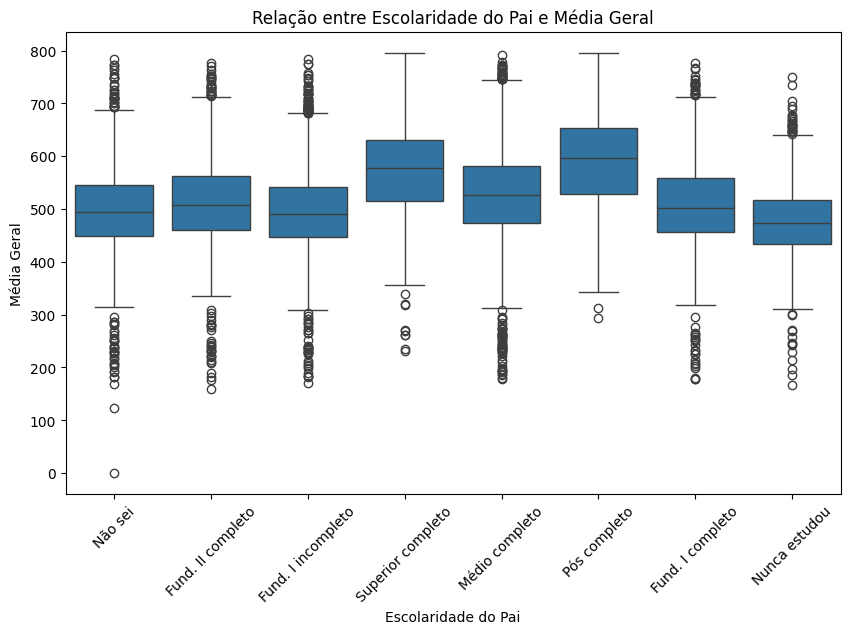

In [19]:
# Escolaridade do pai
plt.figure(figsize=(10, 6))
sns.boxplot(x='ESCOLARIDADE_PAI', y='MEDIA_GERAL', data=df)
plt.xlabel('Escolaridade do Pai')
plt.ylabel('Média Geral')
plt.xticks(rotation=45)
plt.title('Relação entre Escolaridade do Pai e Média Geral')
plt.show()

O mesmo padrão é observado para a escolaridade paterna, indicando que o nível educacional dos responsáveis pode representar um fator relevante para compreender diferenças de desempenho entre os participantes.


In [20]:
mapa_escola = {
    1: 'Não Respondeu',
    2: 'Pública',
    3: 'Privada',
    4: 'Exterior'
}

df['TP_ESCOLA'] = df['TP_ESCOLA'].map(mapa_escola)

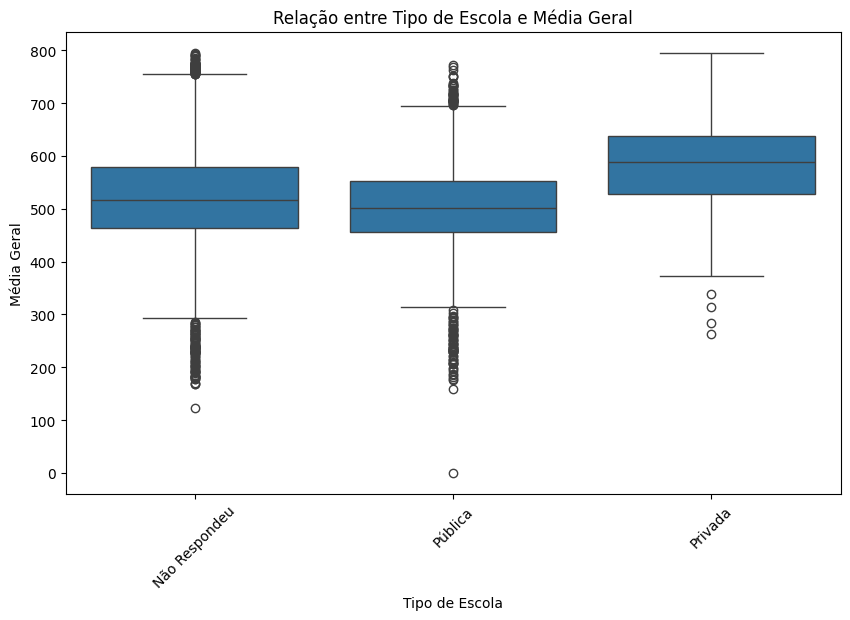

In [21]:
# Tipo de Escola
plt.figure(figsize=(10, 6))
sns.boxplot(x='TP_ESCOLA', y='MEDIA_GERAL', data=df)
plt.xlabel('Tipo de Escola')
plt.ylabel('Média Geral')
plt.xticks(rotation=45)
plt.title('Relação entre Tipo de Escola e Média Geral')
plt.show()

Estudantes de escolas privadas apresentaram mediana de desempenho superior à observada entre estudantes de escolas públicas.
A diferença observada sugere que fatores relacionados à infraestrutura, recursos educacionais e contexto socioeconômico podem influenciar o desempenho dos participantes.

Apesar das tendências observadas, existe sobreposição entre as distribuições dos grupos analisados.
Isso indica que o desempenho é resultado da combinação de diversos fatores e não de uma única característica isolada.


**É possível prever quais estudantes têm maior risco de apresentar baixo desempenho?**

In [22]:
mediana = df['MEDIA_GERAL'].median()
df['BAIXO_DESEMPENHO'] = (df['MEDIA_GERAL'] < mediana).astype(int)

In [23]:
df['BAIXO_DESEMPENHO'].value_counts()

,count
BAIXO_DESEMPENHO,
0,18941
1,18935


In [24]:
features = [
    'Q001',     # Escolaridade do pai
    'Q002',     # Escolaridade da mãe
    'Q006',     # Renda familiar
    'TP_ESCOLA'
]

In [25]:
X = df[features]
Y = df['BAIXO_DESEMPENHO']

In [26]:
X = pd.get_dummies(X, drop_first=True)

In [28]:
X.head()
X.shape
X.isnull().sum().sum()

np.int64(0)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)



**Construindo os modelos**

Regressão Logística

In [30]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000,
)

lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [31]:
y_pred_lr = lr.predict(X_test)

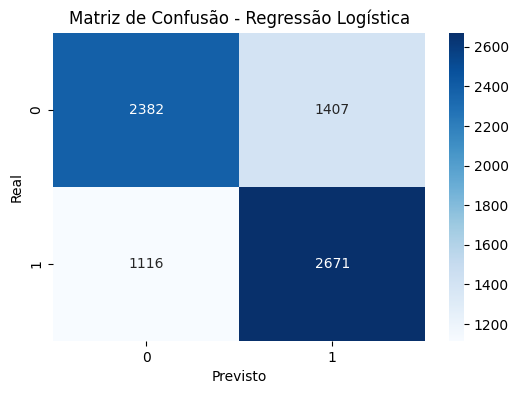

In [36]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Regressão Logística')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

Com a matriz de confusão podemos ver que o modelo conseguiu prever que 2382 alunos não teriam baixo desempenho e que 2671 teria baixo desempenho, ou seja, conseguiu identificar a maioria dos alunos com baixo desempenho mas também comete um erro razoável para falsos positivos(1407).

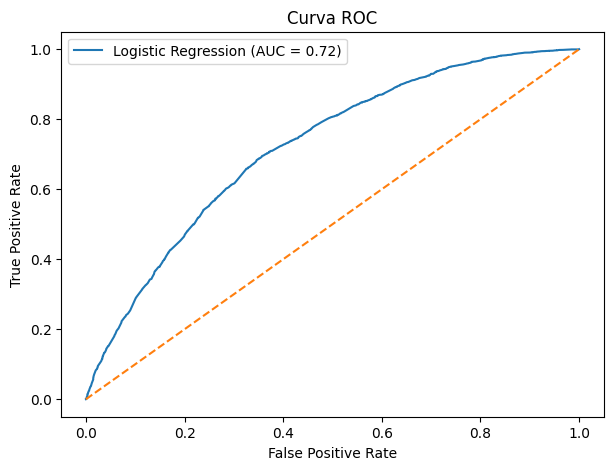

In [46]:
from sklearn.metrics import roc_curve, auc
y_prob_lr = lr.predict_proba(X_test)[:,1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

Random Forest

In [32]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100,
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [33]:
y_pred_rf = rf.predict(X_test)

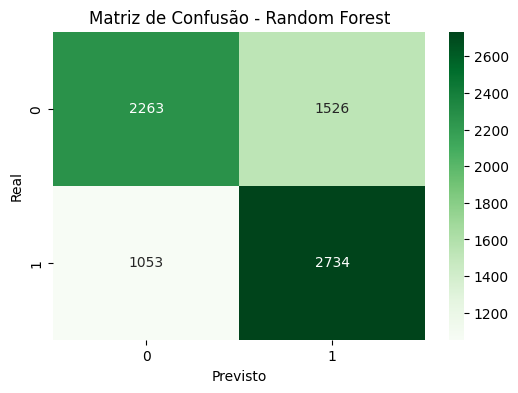

In [39]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - Random Forest')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()



 O modelo Random Forest conseguiu identificar uma proporção ligeiramente maior de alunos com baixo desempenho (Recall de 72.2%) em comparação com a Regressão Logística, mas também teve um número um pouco maior de falsos positivos (1526). A acurácia geral é semelhante à da Regressão Logística, indicando um desempenho razoável, mas com um trade-off ligeiramente diferente entre precisão e recall para a classe positiva.

In [34]:
print(classification_report(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.68      0.63      0.65      3789
           1       0.65      0.71      0.68      3787

    accuracy                           0.67      7576
   macro avg       0.67      0.67      0.67      7576
weighted avg       0.67      0.67      0.67      7576

              precision    recall  f1-score   support

           0       0.68      0.60      0.64      3789
           1       0.64      0.72      0.68      3787

    accuracy                           0.66      7576
   macro avg       0.66      0.66      0.66      7576
weighted avg       0.66      0.66      0.66      7576



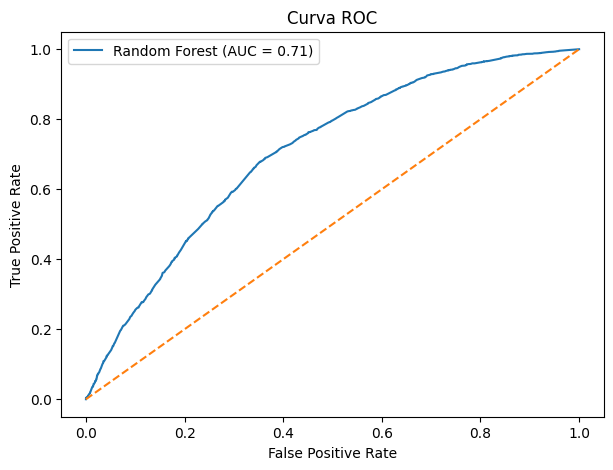

In [48]:
from sklearn.metrics import roc_curve, auc

y_prob_rf = rf.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(7,5))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

**XGBoost**

In [43]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss'),
    param_grid,
    cv=3,
    scoring='f1'
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


In [44]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.69      0.59      0.63      3789
           1       0.64      0.73      0.68      3787

    accuracy                           0.66      7576
   macro avg       0.66      0.66      0.66      7576
weighted avg       0.66      0.66      0.66      7576



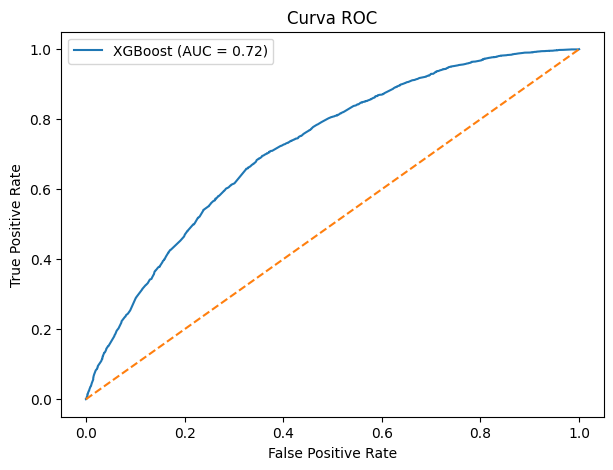

In [49]:
from sklearn.metrics import roc_curve, auc

y_prob_xgb = xgb.predict_proba(X_test)[:,1]

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_lr)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(7,5))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_lr:.2f})')
plt.plot([0,1],[0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

Foram treinados três modelos de classificação para prever estudantes com risco de baixo desempenho no ENEM: Regressão Logística, Random Forest e XGBoost. A Regressão Logística apresentou melhor desempenho geral, com acurácia de 67% e F1-score de 68,0 para a classe de baixo desempenho, superando ligeiramente o Random Forest e XGBoost. Modelos mais complexos não necessariamente superam modelos mais simples quando os dados possuem estrutura relativamente linear. Esse resultado sugere que as variáveis selecionadas possuem capacidade preditiva relevante, ainda que moderada, indicando que fatores socioeconômicos e educacionais contribuem para o desempenho dos estudantes.

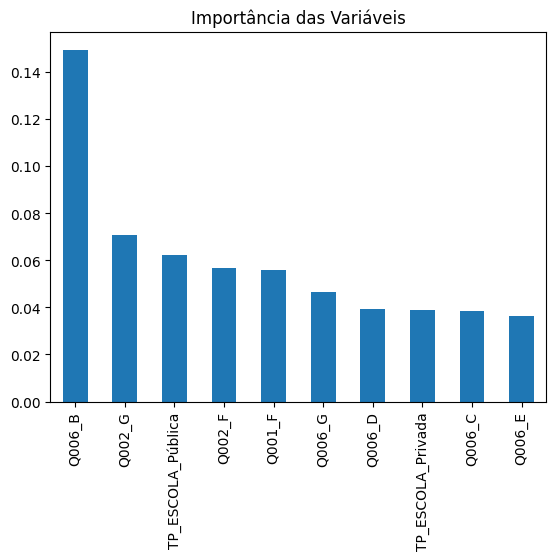

In [35]:
# Importância da variáveis
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

importances.head(10).plot(kind='bar')
plt.title('Importância das Variáveis')
plt.show()


A análise de importância das variáveis demonstrou que fatores socioeconômicos e educacionais possuem papel relevante na previsão de baixo desempenho no ENEM. Entre os atributos mais importantes, destacaram-se a renda familiar, a escolaridade dos pais, e o tipo de escola frequentada pelo participante. Esses resultados reforçam os achados da análise exploratória, evidenciando que desigualdades socias e educacionais estão associadas ao desempenho acadêmico.

Este projeto teve como objetivo investigar fatores associados ao baixo desempenho no ENEM utilizando técnicas de análise de dados e Machine Learning. A análise exploratória revelou associações entre renda familiar, escolaridade dos pais e tipo de escola com o desempenho dos participantes. Na etapa de modelagem, a Regressão Logística apresentou melhor desempenho, alcançando 67% de acurácia e F1-score de 0,68. A análise de importância das variáveis confirmou que fatores socioeconômicos e educacionais possuem relevância preditiva, demonstrando como a ciência de dados pode contribuir para identificar grupos mais vulneráveis e apoiar decisões voltadas à redução das desigualdades educacionais.